In [ ]:
import pandas as pd
import numpy as np
import re
#import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter # extract a slice of an iterator — similar to list slicing, but it works on any iterable (even infinite ones or generators).
from itertools import islice # count/freq of strings

In [ ]:
from datasets import load_dataset
dataset = load_dataset("ai4bharat/IndicCorpV2",split = "mar_Deva" , streaming = True)
display(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

IterableDataset({
    features: Unknown,
    num_shards: 1
})

In [ ]:
#sample values
for i, example in enumerate(islice(dataset, 5)):
    print(f"{example['text']}")

ऊती संवर्धन तंत्राचे अनेक उपयोग आहेत. या तंत्राचा उपयोग विशेषकरून जीवशास्त्र व वैद्यकशास्त्रात होतो. वयोवृद्धी, पोषण, लसनिर्मिती, जन्मजात रोगांचे निदान, इंद्रियांचे रोपण, कर्करोग संशोधन व गर्भपोषण या क्षेत्रांत ऊती संवर्धन तंत्र प्रामुख्याने वापरले जाते. पेशींच्या चयापचयावर एखाद्या घटकाचा परिणाम पाहणे, सामान्य किंवा कर्करोगाच्या पेशींवर औषधांचा होणारा परिणाम पाहणे, प्रयोगशाळेत त्वचा तयार करणे इ. बाबी ऊती संवर्धनामुळे शक्य झाल्या आहेत. भाजलेल्या रुग्णाच्या त्वचारोपणासाठी ऊती संवर्धनाद्वारे निर्माण केलेली त्वचा वापरली जाते.

शहरातील माध्यमिक विभागाच्या शाळा ३ जानेवारीपर्यंत विद्यार्थ्यांसाठी बंद ठेवण्यात येणार आहेत. मात्र, शिक्षकांना शा‌ळेत जाणे अनिवार्य केले आहे. त्यामुळे शिक्षक, शिक्षकेतर कर्मचाऱ्यांना कोरोना तपासणी सक्तीची केली आहे. सोमवारी ५९८ शिक्षकांची तपासणी करण्यात आली. रविवारी २९८ शिक्षकांची तपासणी झाली होती. त्यामध्ये १८ जणांना कोरोनाची बाधा झाल्याचे आढळले.  आतापर्यंत शंभरपेक्षा अधिक शिक्षक, शिक्षकेतर कर्मचारी पॉझिटिव्ह आढळले आहेत.

राणे यांनी शिवसेनेच्या मंत्र्यावर केलेल्या आर

In [ ]:
# Sentence tokenizer
def sentence_tokenizer(text):
    return re.split(r'(?<=[।!?|])\s+', text.strip())
#  ?<=  Lookbehind means: “Match something only if it is immediately preceded by a certain pattern.”
# strip - remove all the space in start , end of sentence
# r' ' - raw string
# Word tokenizer


def word_tokenizer(sentence):
    pattern = r'''(?x)                       #(?x) - tells python re to ignore space , comment in this string
        (https?://[^\s]+)                    # URLs  #:// takes the literal character //
      | (\w+@\w+\.\w+)                       # Emails
      | (\d{1,2}[-/]\d{1,2}[-/]\d{2,4})      # Dates
      | (\d+\.\d+)                           # Decimals
      | (\d+)                                # Whole numbers
      | ([\u0900-\u097F]+)                   # Devanagari (Marathi/Hindi) words   U+0966 – U+096F. for marathi digits
      | ([a-zA-Z]+)                          # English words
      | ([।.,!?;:"'\-—()])                   # Punctuation
    '''
    tokens = re.findall(pattern, sentence)
    #When used with re.findall, each token will go into a separate group.
    # Flatten the list of tuples into a single list
    return [t for group in tokens for t in group if t]


In [ ]:
# this is not used (only for understanding)
# Word tokenizer
#def word_tokenizer(sentence):
    pattern = r'''(?x)
        (?:https?://[^\s]+)                   # URLs
        | (?:\w+@\w+\.\w+)                    # Emails
        | (?:\d{1,2}[-/]\d{1,2}[-/]\d{2,4})   # Dates
        | (?:\d+\.\d+)                        # Decimals
        | (?:\d+)                             # Whole numbers
        | (?:\w+|[^\w\s])                     # Words and punctuation
    '''
  return re.findall(pattern, sentence)
# does not properly tokenize Marathi words (Devanagari script) unless you use Unicode-aware regex.
#Python's \w does not include Devanagari characters by default.
# This is incorrect, as it's splitting valid Marathi words into letters and matras

In [ ]:
pattern = r'''(?x)
        (?:https?://[^\s]+)                   # URLs
        | (?:\w+@\w+\.\w+)                    # Emails
        | (?:\d{1,2}[-/]\d{1,2}[-/]\d{2,4})   # Dates
        | (?:\d+\.\d+)                        # Decimals
        | (?:\d+)                             # Whole numbers
        | (?:\w+|[^\w\s])                     # Words and punctuation
    '''
  return re.findall(pattern, sentence)

In [ ]:
sentence = sentence_tokenizer('मजकुराचा पैलू  मागील कॅमेरा ?, ड्युअल टोन!! एल. ई. डी. फ्लॅश आणि फिंगरप्रिंट स्कॅनरची सेटअप वैशिष्ट्ये रेडमी नोट 3 सारखीच आहेत|')
print(sentence)
#Split the text wherever there is a space following a sentence-ending punctuation mark (।, !, ?, or |)

['मजकुराचा पैलू  मागील कॅमेरा ?, ड्युअल टोन!!', 'एल. ई. डी. फ्लॅश आणि फिंगरप्रिंट स्कॅनरची सेटअप वैशिष्ट्ये रेडमी नोट 3 सारखीच आहेत|']


In [ ]:
#using the unicode- aware tokenizer
words = word_tokenizer(sentence[-1])
print(words)

['एल', '.', 'ई', '.', 'डी', '.', 'फ्लॅश', 'आणि', 'फिंगरप्रिंट', 'स्कॅनरची', 'सेटअप', 'वैशिष्ट्ये', 'रेडमी', 'नोट', '3', 'सारखीच', 'आहेत']


In [ ]:
words = word_tokenizer("राम पुण्याला गेला। He met Sita on 12-08-2025! Visit http://abc.com")
print(words)

['राम', 'पुण्याला', 'गेला।', 'He', 'met', 'Sita', 'on', '12-08-2025', '!', 'Visit', 'http://abc.com']


In [ ]:
#for the sake of future assignments , i have reduced the sample size to 100000
max_examples = 100000
tokenized_sentences = []
total_words = 0
total_chars = 0
unique_tokens = set()
# Safely iterate over streaming dataset with limit
for example in islice(dataset, max_examples): # word, freq
    text = example["text"]
    sentences = sentence_tokenizer(text)
    for sentence in sentences:
        tokens = word_tokenizer(sentence)
        if tokens:
            tokenized_sentence = " ".join(tokens)
            tokenized_sentences.append(tokenized_sentence)
            total_words += len(tokens)
            total_chars += sum(len(t) for t in tokens)
            unique_tokens.update(tokens)

# Step 4: Save to file
df = pd.DataFrame({'sentence': tokenized_sentences})

import csv

df.to_csv(
    "marathi_tokenized_sentences_fixed.csv",
    index=False,
    encoding='utf-8-sig',
    quoting=csv.QUOTE_ALL,
    lineterminator='\n'  # Correct argument name
)


# Corpus statistics
num_sentences = len(tokenized_sentences)
avg_sentence_length = total_words / num_sentences
avg_word_length = total_chars / total_words
ttr = len(unique_tokens) / total_words
#High TTR → greater vocabulary variety
#Low TTR → more repetition, less variety
token_count = len(unique_tokens)
print("Corpus Statistics:")
print(f"Total number of sentences: {num_sentences}")
print(f"Total number of words: {total_words}")
print(f"Unique_tokens:{token_count}")
print(f"Total number of characters: {total_chars}")
print(f"Average sentence length: {avg_sentence_length:.2f}")
print(f"Average word length: {avg_word_length:.2f}")
print(f"Type/Token Ratio (TTR): {ttr:.4f}")

Corpus Statistics:
Total number of sentences: 54791
Total number of words: 2386442
Unique_tokens:204170
Total number of characters: 12213042
Average sentence length: 43.56
Average word length: 5.12
Type/Token Ratio (TTR): 0.0856


In [ ]:
df.shape

(54791, 1)

In [ ]:
df1 = pd.read_csv("/content/marathi_tokenized_sentences_fixed.csv")
df1.head()

,sentence
0,ऊती संवर्धन तंत्राचे अनेक उपयोग आहेत . या तंत्...
1,शहरातील माध्यमिक विभागाच्या शाळा ३ जानेवारीपर्...
2,राणे यांनी शिवसेनेच्या मंत्र्यावर केलेल्या आरो...
3,त्यामुळे शिरूर तालुक् यात आतापर्यंत आढळलेल्या ...
4,प्रत्येक हॅास्पीटलला २५ ते ३० टक्के ॲाक्सीजनचा...


 ✅ For CSV files opened in Excel:
When opening in Excel:

Don't double-click to open!

Instead:

Open Excel.

Go to File > Open > Browse.

In the Open dialog, select "All Files" and choose your CSV.

You'll get a Text Import Wizard:

Select "65001: Unicode (UTF-8)" as the encoding.

Use comma (,) as delimiter.

Finish.

This will render Marathi text correctly.

In [ ]:
#!pip install pyarrow
# Assuming df is your DataFrame with tokenized sentences
df.to_parquet("marathi_tokenized_sentences.parquet", engine='pyarrow', compression='snappy', index=False)


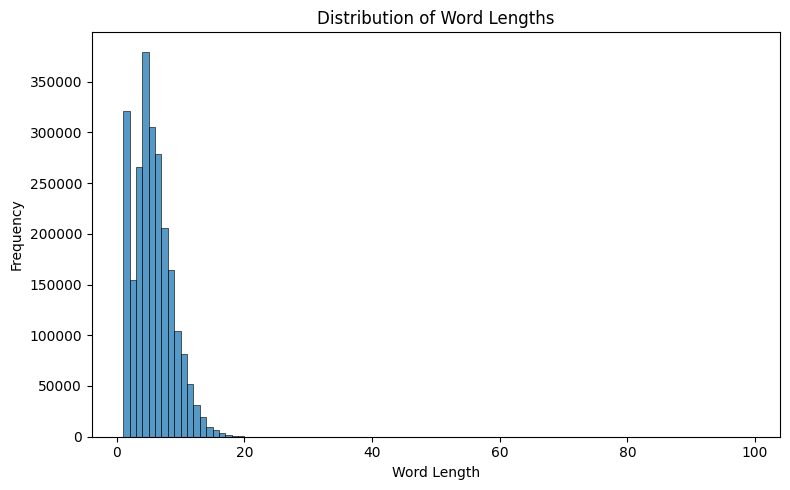

In [ ]:
word_lengths = [len(word) for sentence in tokenized_sentences for word in sentence.split()]
sentence_lengths = [len(sentence.split()) for sentence in tokenized_sentences]
all_words = [word for sentence in tokenized_sentences for word in sentence.split()]
word_freq = Counter(all_words).most_common(20)
# Plot 1: Word Length Distribution
plt.figure(figsize=(8, 5))
sns.histplot(word_lengths, bins=range(1, max(word_lengths) + 1), kde=False)
plt.title("Distribution of Word Lengths")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

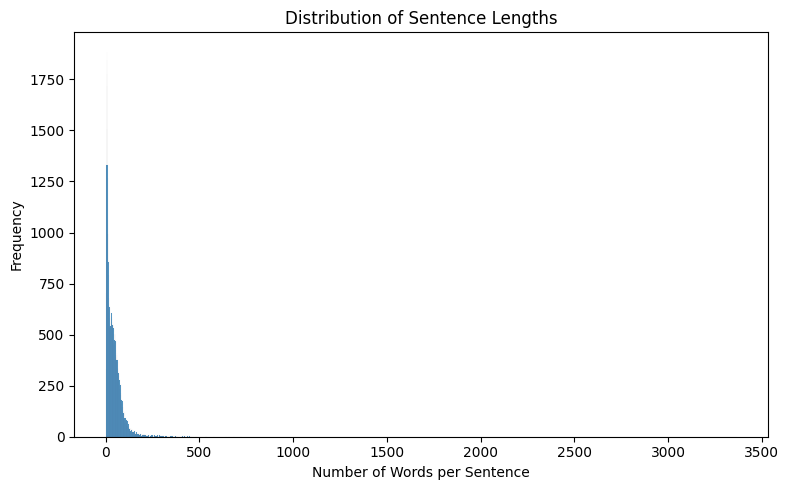

In [ ]:
# Plot 2: Sentence Length Distribution
plt.figure(figsize=(8, 5))
sns.histplot(sentence_lengths, bins=range(1, max(sentence_lengths) + 1), kde=False)
plt.title("Distribution of Sentence Lengths")
plt.xlabel("Number of Words per Sentence")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# **LAB-4**

In [ ]:
import nltk
from collections import Counter


In [ ]:
df1.head()

,sentence
0,ऊती संवर्धन तंत्राचे अनेक उपयोग आहेत . या तंत्...
1,शहरातील माध्यमिक विभागाच्या शाळा ३ जानेवारीपर्...
2,राणे यांनी शिवसेनेच्या मंत्र्यावर केलेल्या आरो...
3,त्यामुळे शिरूर तालुक् यात आतापर्यंत आढळलेल्या ...
4,प्रत्येक हॅास्पीटलला २५ ते ३० टक्के ॲाक्सीजनचा...


In [ ]:
# Corpus statistics
num_sentences = len(tokenized_sentences)
avg_sentence_length = total_words / num_sentences
avg_word_length = total_chars / total_words
ttr = len(unique_tokens) / total_words
#High TTR → greater vocabulary variety
#Low TTR → more repetition, less variety
token_count = len(unique_tokens)
print("Corpus Statistics:")
print(f"Total number of sentences: {num_sentences}")
print(f"Total number of words: {total_words}")
print(f"Unique_tokens:{token_count}")
print(f"Total number of characters: {total_chars}")
print(f"Average sentence length: {avg_sentence_length:.2f}")
print(f"Average word length: {avg_word_length:.2f}")
print(f"Type/Token Ratio (TTR): {ttr:.4f}")

Corpus Statistics:
Total number of sentences: 54791
Total number of words: 2386442
Unique_tokens:204170
Total number of characters: 12213042
Average sentence length: 43.56
Average word length: 5.12
Type/Token Ratio (TTR): 0.0856


In [ ]:
df1.shape

(54791, 1)

In [ ]:
corpus = df1['sentence'].tolist()

In [ ]:
#unigrams
unigrams = Counter()
for sentence in corpus:
    words = sentence.split()
    unigrams.update(words)


In [ ]:
print(unigrams)
print(len(unigrams))
print(sum(unigrams.values()))

Counter({'.': 168357, ',': 71115, 'आहे': 51383, 'आणि': 26463, 'या': 24337, '-': 15029, 'आहेत': 12666, 'नाही': 11172, 'हे': 10556, 'यांनी': 9877, 'तर': 9361, 'ते': 8287, ')': 7942, 'होते': 7716, '(': 7596, 'व': 7442, 'केली': 7394, 'एक': 7222, ':': 7012, 'हा': 6869, "'": 6779, 'ही': 6496, 'करण्यात': 6331, 'काही': 6190, 'असे': 5921, 'केले': 5624, 'होती': 5430, 'की': 5333, 'केला': 5323, 'पण': 5077, 'होता': 4859, '?': 4805, 'आता': 4537, 'त्यामुळे': 4523, 'मात्र': 4451, 'आले': 4316, 'त्यांनी': 4050, 'आली': 4027, 'असून': 3992, 'झाली': 3882, 'करून': 3652, 'त्या': 3652, 'आपल्या': 3651, 'झाला': 3618, 'एका': 3583, 'झाले': 3468, 'अनेक': 3464, 'मी': 3424, 'अशी': 3422, 'यांच्या': 3415, 'सुरू': 3350, 'आला': 3333, 'करत': 3315, 'म्हणून': 3296, 'तो': 3228, 'दोन': 3137, 'माहिती': 3108, 'त्यांना': 3080, 'सर्व': 2996, 'मुंबई': 2982, '"': 2979, 'तसेच': 2958, 'असा': 2890, 'दिली': 2872, 'आज': 2868, '!': 2838, 'किंवा': 2816, 'होत': 2764, 'ती': 2755, 'मध्ये': 2711, 'काम': 2681, 'त्यांच्या': 2665, 'काय': 2665, '

In [ ]:
#bigrams
#bigrams = Counter()
#for sentence in corpus:
#    words = sentence.split()
#    for i in range(len(words) - 1):
#        bigram = (words[i], words[i + 1])
#        bigrams[bigram] += 1
#trigrams
#trigrams = Counter()
#for sentence in corpus:
#  words = sentence.split()
#  for i in range(len(words)-2):
#    trigram = (words[i],words[i+1],words[i+2])
#    trigrams[trigram] += 1
##quadrigrams
#quadrigrams = Counter()
#for sentence in corpus:
#  words = sentence.split()
#  for i in range(len(words)-3):
#    quadrigram = (words[i],words[i+1],words[i+2],words[i+3])
#    quadrigrams[quadrigram] += 1

In [ ]:
bigrams = Counter()
for sentence in corpus:
    tokens = sentence.split()
    for bg in nltk.bigrams(tokens):
        bigrams[bg] += 1

In [ ]:
# Number of unique bigrams
print("Number of unique bigrams:", len(bigrams))

# Top 10 most frequent bigrams
print("Top 10 bigrams:", bigrams.most_common(10))


Number of unique bigrams: 1242191
Top 10 bigrams: [(('आहे', '.'), 42644), (('आहेत', '.'), 10284), (('.', '.'), 8256), (('.', 'या'), 6208), (('नाही', '.'), 6158), (('होते', '.'), 6137), (('होती', '.'), 4447), (('होता', '.'), 3824), (('.', 'त्यामुळे'), 3673), (('आहे', ','), 2945)]


In [ ]:
trigrams = Counter()
for sentence in corpus:
  tokens = sentence.split()
  for tg in nltk.trigrams(tokens):
    trigrams[tg] += 1

In [ ]:
# Number of unique trigrams
print("Number of unique trigrams:", len(trigrams))

# Top 10 most frequent trigrams
print("Top 10 trigrams:", trigrams.most_common(10))

Number of unique trigrams: 1870866
Top 10 trigrams: [(('.', '.', '.'), 4049), (('आहे', '.', 'या'), 2089), (('केली', 'आहे', '.'), 1846), (('-', '-', '-'), 1531), (('आली', 'आहे', '.'), 1499), (('आहे', '.', 'त्यामुळे'), 1305), (('केला', 'आहे', '.'), 1233), (('आला', 'आहे', '.'), 1200), (('.', 'मात्र', ','), 1125), (('झाली', 'आहे', '.'), 1111)]


In [ ]:
quadrigrams = Counter()
for sentence in corpus:
  tokens = sentence.split()
  for qg in nltk.ngrams(tokens,4):
    quadrigrams[qg] += 1

In [ ]:
#Number of unique quadrigrams
print("Number of unique quadrigrams:", len(quadrigrams))

# Top 10 most frequent quadrigrams
print("Top 10 quadrigrams:", quadrigrams.most_common(10))

Number of unique quadrigrams: 2088183
Top 10 quadrigrams: [(('-', '-', '-', '-'), 1461), (('.', '.', '.', '.'), 1264), (('करण्यात', 'आली', 'आहे', '.'), 645), (('करण्यात', 'आला', 'आहे', '.'), 482), (('करण्यात', 'आले', 'आहे', '.'), 359), (('देण्यात', 'आली', 'आहे', '.'), 251), (('आहे', '.', 'मात्र', ','), 243), (('मृत्यू', 'झाला', 'आहे', '.'), 230), (('करण्यात', 'येणार', 'आहे', '.'), 223), (('गुन्हा', 'दाखल', 'करण्यात', 'आला'), 221)]


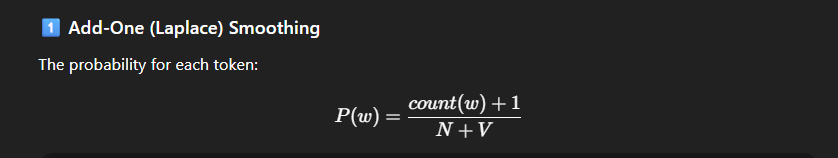

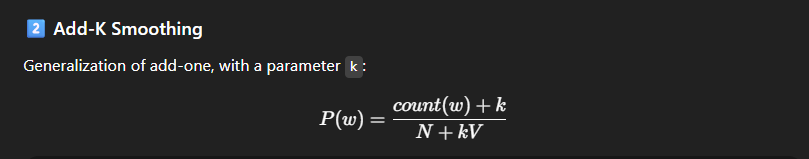

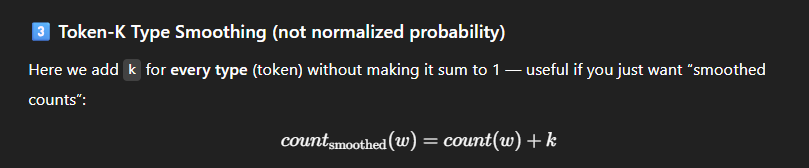

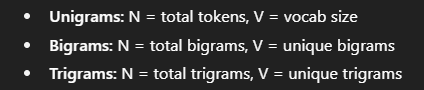

In [ ]:
#for trigrams
def add_one_smoothing(counter):
    total_tokens = sum(counter.values())
    V = len(counter)
    smoothed_probs = {token: (count + 1) / (total_tokens + V) for token, count in counter.items()}
    return smoothed_probs

add_one_probs = add_one_smoothing(trigrams)
print(list(add_one_probs.items())[:5])


[(('ऊती', 'संवर्धन', 'तंत्राचे'), 4.821535678399713e-07), (('संवर्धन', 'तंत्राचे', 'अनेक'), 4.821535678399713e-07), (('तंत्राचे', 'अनेक', 'उपयोग'), 4.821535678399713e-07), (('अनेक', 'उपयोग', 'आहेत'), 4.821535678399713e-07), (('उपयोग', 'आहेत', '.'), 4.821535678399713e-07)]


In [ ]:
def add_k_smoothing(counter, k=0.5):
    total_tokens = sum(counter.values())
    V = len(counter)
    smoothed_probs = {token: (count + k) / (total_tokens + k * V) for token, count in counter.items()}
    return smoothed_probs

add_k_probs = add_k_smoothing(trigrams, k=0.5)
print(list(add_k_probs.items())[:5])


[(('ऊती', 'संवर्धन', 'तंत्राचे'), 4.669081930870818e-07), (('संवर्धन', 'तंत्राचे', 'अनेक'), 4.669081930870818e-07), (('तंत्राचे', 'अनेक', 'उपयोग'), 4.669081930870818e-07), (('अनेक', 'उपयोग', 'आहेत'), 4.669081930870818e-07), (('उपयोग', 'आहेत', '.'), 4.669081930870818e-07)]


In [ ]:
from collections import Counter
import math

def smooth_ngrams(counter, method="add-one", k=1, n=1, vocab_size=None):
    """
    Smooth n-gram counts.

    Parameters:
        counter : Counter
            Dictionary of n-gram counts.
        method : str
            "add-one"      -> Laplace smoothing
            "add-k"        -> Add-k smoothing
            "token-k"      -> Add k to counts (not normalized)
            "good-turing"  -> Good-Turing smoothing (requires vocab_size and n)
        k : float
            Value for add-k or token-k type smoothing
        n : int
            n-gram order (1 = unigram, 2 = bigram, etc.)
        vocab_size : int
            Vocabulary size (V). Required for Good-Turing smoothing.

    Returns:
        dict : Smoothed probabilities for seen n-grams
        float : Probability for each unseen n-gram (only for Good-Turing)
    """

    total_tokens = sum(counter.values())
    V = len(counter) if vocab_size is None else vocab_size

    # ADD-ONE (Laplace)
    if method == "add-one":
        return {ngram: (count + 1) / (total_tokens + V) for ngram, count in counter.items()}

    # --- ADD-K ---
    elif method == "add-k":
        return {ngram: (count + k) / (total_tokens + k * V) for ngram, count in counter.items()}

    # --- TOKEN-K ---
    elif method == "token-k":
        return {ngram: count + k for ngram, count in counter.items()}

    # --- GOOD TURING ---
    elif method == "good-turing":

        Nc = Counter(counter.values())

        N = len(counter)             # total number of seen n-grams (unique)
        N1 = Nc.get(1, 0)            # number of n-grams that occurred once

        +# Compute unseen count space:
        if n == 1:
            # For unigram model: unseen = V - U
            U = N                    # unique seen unigrams
            unseen_ngrams = max(V - U, 1)
        else:
            # For n >= 2: unseen = V**n - N
            unseen_ngrams = max(V**n - N, 1)

        # Cumulative probability mass for unseen n-grams
        P_unseen_total = N1 / N if N > 0 else 0.0
        # Probability for each unseen n-gram
        P_unseen_each = P_unseen_total / unseen_ngrams

        # Compute adjusted count for each seen n-gram:
        c_star = {}
        for ngram, c in counter.items():
            Nc_next = Nc.get(c + 1, 0)
            if Nc_next > 0:
                # Good-Turing adjusted count
                c_star_val = (c + 1) * Nc_next / Nc[c]
            else:
                # If Nc+1 = 0, use raw count (fallback)
                c_star_val = c
            c_star[ngram] = c_star_val

        # Normalize to probabilities:
        total_c_star = sum(c_star.values())
        smoothed_probs = {ng: val / total_c_star for ng, val in c_star.items()}

        return smoothed_probs, P_unseen_each

    else:
        raise ValueError("Unknown smoothing method. Choose 'add-one', 'add-k', 'token-k', or 'good-turing'.")

# Example usage for unigrams, bigrams, trigrams...
# Suppose you already have:
# unigrams = Counter({...})
# bigrams = Counter({...})
# trigrams = Counter({...})

for ngram_name, ngram_counter in [("unigrams", unigrams), ("bigrams", bigrams),("trigrams",trigrams),("quadrigrams",quadrigrams)]:
    print(f"--- {ngram_name} ---")
    print("Token-K smoothed counts:", list(smooth_ngrams(ngram_counter, method="token-k", k=1).items())[:5])
    print("Add-K smoothed probs:", list(smooth_ngrams(ngram_counter, method="add-k", k=0.5).items())[:5])
    print("Add-One smoothed probs:", list(smooth_ngrams(ngram_counter, method="add-one").items())[:5])
    # Modified this line to unpack the tuple
    good_turing_result, unseen_prob = smooth_ngrams(ngram_counter, method="good-turing", n=1, vocab_size=len(ngram_counter))
    print("Good Turing smoothed probs:", list(good_turing_result.items())[:5])
    #here unseen prob is for unseen gram prob using good turing

--- unigrams ---
Token-K smoothed counts: [('ऊती', 6), ('संवर्धन', 49), ('तंत्राचे', 4), ('अनेक', 3465), ('उपयोग', 247)]
Add-K smoothed probs: [('ऊती', 2.2101427872793825e-06), ('संवर्धन', 1.9489440942372736e-05), ('तंत्राचे', 1.4064545009959707e-06), ('अनेक', 0.00139218903391444), ('उपयोग', 9.90545812844305e-05)]
Add-One smoothed probs: [('ऊती', 2.3160550479963808e-06), ('संवर्धन', 1.891444955863711e-05), ('तंत्राचे', 1.544036698664254e-06), ('अनेक', 0.00133752179021791), ('उपयोग', 9.534426614251768e-05)]
Good Turing smoothed probs: [('ऊती', 1.8891944890209627e-06), ('संवर्धन', 2.0130629321734158e-05), ('तंत्राचे', 1.0471243465041634e-06), ('अनेक', 0.0015259878282206426), ('उपयोग', 0.00014508044402251682)]
--- bigrams ---
Token-K smoothed counts: [(('ऊती', 'संवर्धन'), 3), (('संवर्धन', 'तंत्राचे'), 2), (('तंत्राचे', 'अनेक'), 2), (('अनेक', 'उपयोग'), 2), (('उपयोग', 'आहेत'), 2)]
Add-K smoothed probs: [(('ऊती', 'संवर्धन'), 8.466693635908128e-07), (('संवर्धन', 'तंत्राचे'), 5.080016181544877

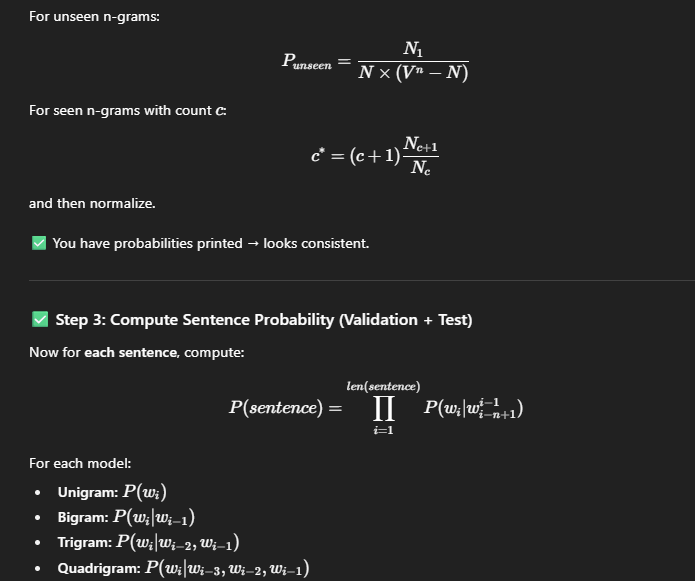

In [ ]:
import math
from collections import Counter

unigram_probs = smooth_ngrams(unigrams, method="add-one")
bigram_probs = smooth_ngrams(bigrams, method="add-k", k=0.5)
trigram_probs = smooth_ngrams(trigrams, method="add-k", k=0.5)
quadgram_probs = smooth_ngrams(quadrigrams, method="add-k", k=0.5)


def compute_sentence_probabilities(sentence, ngram_probs_list):
    tokens = sentence.split()
    results = {}

    ngram_names = ["unigrams", "bigrams", "trigrams", "quadgrams"]

    for n, ngram_probs in enumerate(ngram_probs_list, start=1):
        prob = 1.0
        log_prob = 0.0

        if n == 1:
            for w in tokens:
                p = ngram_probs.get(w, 1e-8)  # tiny prob for unseen words
                prob *= p
                log_prob += math.log(p)

        else:
            for i in range(len(tokens) - n + 1):
                ngram = tuple(tokens[i:i+n])
                p = ngram_probs.get(ngram, 1e-8)  # tiny prob for unseen n-grams
                prob *= p
                log_prob += math.log(p)

        results[ngram_names[n-1]] = (prob, log_prob)

    return results

# Example usage:
sentence = "आपल्या देशात बातम्या खूप महत्वाच्या आहेत"
ngram_probs_list = [unigram_probs, bigram_probs, trigram_probs, quadgram_probs]
probs = compute_sentence_probabilities(sentence, ngram_probs_list)

for ngram_type, (p, logp) in probs.items():
    print(f"{ngram_type}: Prob = {p:.5e}, Log-Prob = {logp:.5f}")


unigrams: Prob = 1.33315e-21, Log-Prob = -48.06674
bigrams: Prob = 6.45164e-36, Log-Prob = -81.02873
trigrams: Prob = 1.00000e-32, Log-Prob = -73.68272
quadgrams: Prob = 1.00000e-24, Log-Prob = -55.26204


In [ ]:
import random

evaluation_sentences = random.sample(tokenized_sentences, 1000)


LAB-5

In [ ]:
import random

random.seed(42)  # reproducibility

# Shuffle all sentences
random.shuffle(tokenized_sentences)

# Check total count first
total = len(sentences)
print(f"Total sentences: {total}")
# Split
validation_set = tokenized_sentences[:1000]
test_set = tokenized_sentences[1000:2000]
training_set = tokenized_sentences[2000:]

# Summary
print(f"Training set: {len(training_set)} sentences")
print(f"Validation set: {len(validation_set)} sentences")
print(f"Test set: {len(test_set)} sentences")


Total sentences: 1
Training set: 52791 sentences
Validation set: 1000 sentences
Test set: 1000 sentences


In [ ]:
from collections import Counter
import pandas as pd

def good_turing_table(counter, top_n=100):
    #Frequency of frequencies
    freq_of_freq = Counter(counter.values())

    #Prepare list of sorted counts (C)
    sorted_C = sorted(freq_of_freq.keys())

    #Compute adjusted counts C*
    adjusted_counts = {}
    for c in sorted_C:
        Nc = freq_of_freq[c]
        Nc1 = freq_of_freq.get(c + 1, 0)
        if Nc1 > 0:
            c_star = (c + 1) * Nc1 / Nc
        else:
            c_star = c  # fallback if Nc+1 = 0
        adjusted_counts[c] = c_star

    data = []
    for c in sorted_C[:top_n]:
        Nc = freq_of_freq[c]
        c_star = adjusted_counts[c]
        data.append((c, Nc, c_star))

    df = pd.DataFrame(data, columns=["C (MLE)", "Nc", "C*"])
    return df

# Example usage
unigram_table = good_turing_table(unigrams, top_n=100)
bigram_table = good_turing_table(bigrams, top_n=100)

print(unigram_table.head(20))


    C (MLE)      Nc         C*
0         1  121858   0.441317
1         2   26889   1.403436
2         3   12579   2.376978
3         4    7475   3.315719
4         5    4957   4.288481
5         6    3543   5.510302
6         7    2789   6.247401
7         8    2178   7.504132
8         9    1816   8.650881
9        10    1571   9.522597
10       11    1360   9.494118
11       12    1076  11.634758
12       13     963  12.647975
13       14     870  12.931034
14       15     750  14.293333
15       16     670  15.046269
16       17     593  16.876897
17       18     556  17.188849
18       19     503  18.290258
19       20     460  18.534783


In [ ]:
def deleted_interpolation_lambdas(unigrams, bigrams, trigrams, quadrigrams):
    """
    Estimate lambdas for deleted interpolation more efficiently.
    """
    lambda_counts = [0.0, 0.0, 0.0, 0.0]
    total = 0.0

    N = sum(unigrams.values())  # precompute total tokens

    # Precompute denominators only once
    unigram_total = N
    bigram_den = {bg: unigrams.get(bg[0], 1) for bg in bigrams}
    trigram_den = {tg: bigrams.get((tg[0], tg[1]), 1) for tg in trigrams}
    quad_den = {qg: trigrams.get((qg[0], qg[1], qg[2]), 1) for qg in quadrigrams}

    for (w1, w2, w3, w4), c4 in quadrigrams.items():
        if c4 < 1:
            continue

        c3 = trigrams.get((w1, w2, w3), 0)
        c2 = bigrams.get((w2, w3), 0)
        c1 = unigrams.get(w3, 0)

        if c3 == 0 or c2 == 0 or c1 == 0:
            continue

        # Precompute once
        p4 = (c4 - 1) / c3 if c3 > 1 else 0
        p3 = (trigrams.get((w2, w3, w4), 0) - 1) / c2 if c2 > 1 else 0
        p2 = (bigrams.get((w3, w4), 0) - 1) / c1 if c1 > 1 else 0
        p1 = (unigrams.get(w4, 0) - 1) / unigram_total if unigram_total > 1 else 0

        probs = [p1, p2, p3, p4]
        best = max(range(4), key=lambda i: probs[i])  # faster than probs.index(max(probs))

        lambda_counts[best] += c4
        total += c4

    lambdas = [lc / total for lc in lambda_counts]
    return lambdas


In [ ]:
import random

def sample_counter(counter, fraction=0.1):
    items = list(counter.items())
    sample_size = int(len(items) * fraction)
    sampled = dict(random.sample(items, sample_size))
    return sampled

sampled_quads = sample_counter(quadrigrams, 0.1)
lambdas = deleted_interpolation_lambdas(unigrams, bigrams, trigrams, sampled_quads)
print(lambdas)

[0.47091947695667474, 0.34454892476514487, 0.14216743522871866, 0.04236416304946171]


In [ ]:
def interpolated_prob(w1, w2, w3, w4, lambdas, unigram_probs, bigram_probs, trigram_probs, quad_probs):
    p1 = unigram_probs.get(w4, 0)
    p2 = bigram_probs.get((w3, w4), 0)
    p3 = trigram_probs.get((w2, w3, w4), 0)
    p4 = quad_probs.get((w1, w2, w3, w4), 0)
    return lambdas[0]*p1 + lambdas[1]*p2 + lambdas[2]*p3 + lambdas[3]*p4


In [ ]:
w1, w2, w3, w4 = "मी", "शाळेत", "जातो","|"

prob = interpolated_prob(w1, w2, w3, w4, lambdas,
                         unigram_probs, bigram_probs, trigram_probs, quad_probs)

print("Interpolated Probability:", prob)


Interpolated Probability: 0.016700000000000003


# **LAB-6**

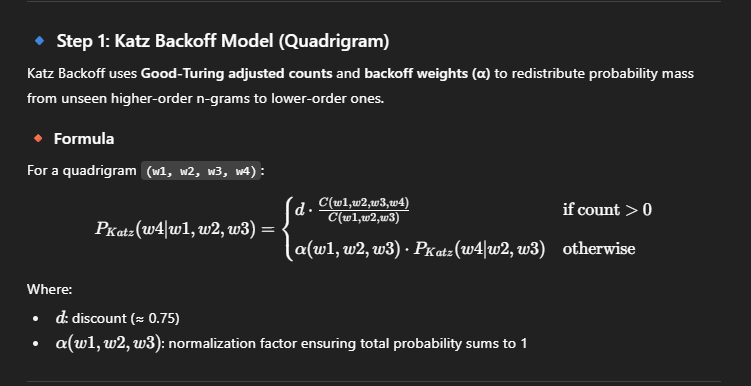

In [ ]:
from collections import defaultdict

discount = 0.75

def katz_backoff_prob(w1, w2, w3, w4, quad_counts, tri_counts, bi_counts, uni_counts, vocab):
    quad = (w1, w2, w3, w4)
    tri = (w1, w2, w3)

    # Case 1: Seen quadrigram
    if quad_counts[quad] > 0:
        return max(quad_counts[quad] - discount, 0) / tri_counts[tri]

    # Case 2: Backoff to trigram
    observed_w4s = [w for w in vocab if quad_counts[(w1, w2, w3, w)] > 0]
    alpha = 1 - sum((max(quad_counts[(w1, w2, w3, w)] - discount, 0) / tri_counts[tri]) for w in observed_w4s)

    return alpha * katz_backoff_prob_tri(w2, w3, w4, tri_counts, bi_counts, uni_counts, vocab)


def katz_backoff_prob_tri(w2, w3, w4, tri_counts, bi_counts, uni_counts, vocab):
    tri = (w2, w3, w4)
    bi = (w2, w3)

    # Case 1: Seen trigram
    if tri_counts[tri] > 0:
        return max(tri_counts[tri] - discount, 0) / bi_counts[bi]

    # Case 2: Backoff to bigram
    observed_w4s = [w for w in vocab if tri_counts[(w2, w3, w)] > 0]
    alpha = 1 - sum((max(tri_counts[(w2, w3, w)] - discount, 0) / bi_counts[bi]) for w in observed_w4s)

    return alpha * katz_backoff_prob_bi(w3, w4, bi_counts, uni_counts, vocab)


def katz_backoff_prob_bi(w3, w4, bi_counts, uni_counts, vocab):
    bi = (w3, w4)

    # Case 1: Seen bigram
    if bi_counts[bi] > 0:
        return max(bi_counts[bi] - discount, 0) / uni_counts[w3]

    # Case 2: Backoff to unigram
    observed_w4s = [w for w in vocab if bi_counts[(w3, w)] > 0]
    alpha = 1 - sum((max(bi_counts[(w3, w)] - discount, 0) / uni_counts[w3]) for w in observed_w4s)

    return alpha * katz_backoff_prob_uni(w4, uni_counts, vocab)


def katz_backoff_prob_uni(w, uni_counts, vocab):
    total = sum(uni_counts.values())
    if total == 0:
        return 1 / len(vocab)
    return uni_counts[w] / total


In [ ]:
continuation_counts = Counter()

for (w1, w2) in bigrams.keys():
    continuation_counts[w2] += 1

vocab = set(unigrams.keys())

print(katz_backoff_prob('उपयोग','करण्यात','केली','आहेत',quadrigrams,trigrams,bigrams,continuation_counts,vocab))

0.053814199395770396


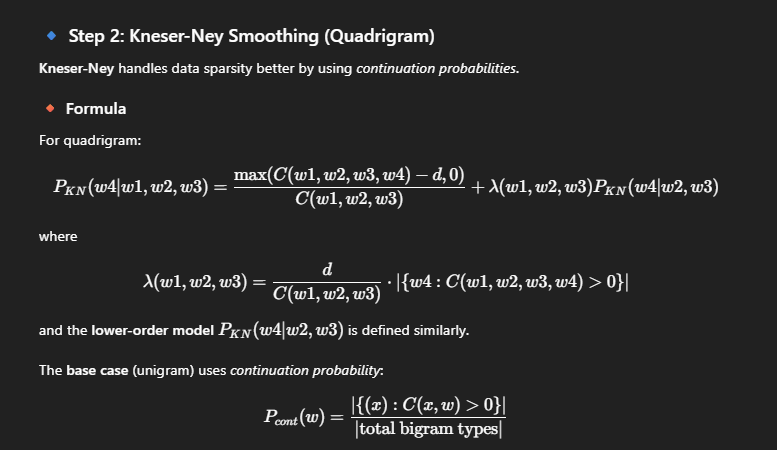

In [ ]:
def kneser_ney_prob(w1, w2, w3, w4, quad_counts, tri_counts, bi_counts, continuation_counts, vocab, d=0.75):
    quad = (w1, w2, w3, w4)
    tri = (w1, w2, w3)

    numerator = max(quad_counts[quad] - d, 0)
    denominator = tri_counts[tri] if tri_counts[tri] > 0 else 1
    prob = numerator / denominator

    # lambda
    unique_followers = len([w for w in vocab if quad_counts[(w1, w2, w3, w)] > 0])
    lamb = (d * unique_followers) / denominator

    # Backoff
    backoff_prob = kneser_ney_tri_prob(w2, w3, w4, tri_counts, bi_counts, continuation_counts, vocab, d)

    return prob + lamb * backoff_prob


In [ ]:
def kneser_ney_tri_prob(w2, w3, w4, tri_counts, bi_counts, continuation_counts, vocab, d=0.75):
    tri = (w2, w3, w4)
    bi = (w2, w3)

    numerator = max(tri_counts[tri] - d, 0)
    denominator = bi_counts[bi] if bi_counts[bi] > 0 else 1
    prob = numerator / denominator

    # lambda
    unique_followers = len([w for w in vocab if tri_counts[(w2, w3, w)] > 0])
    lamb = (d * unique_followers) / denominator

    # backoff probability (to bigram)
    backoff_prob = kneser_ney_bi_prob(w3, w4, bi_counts, continuation_counts, vocab, d)

    return prob + lamb * backoff_prob


In [ ]:
def kneser_ney_bi_prob(w3, w4, bi_counts, continuation_counts, vocab, d=0.75):
    bi = (w3, w4)
    numerator = max(bi_counts[bi] - d, 0)
    denominator = sum(count for (x, y), count in bi_counts.items() if x == w3)
    prob = numerator / denominator if denominator > 0 else 0

    # lambda
    unique_followers = len([w for w in vocab if bi_counts[(w3, w)] > 0])
    lamb = (d * unique_followers) / denominator if denominator > 0 else 0

    # unigram continuation prob
    cont_total = sum(continuation_counts.values())
    p_cont = continuation_counts[w4] / cont_total if cont_total > 0 else 1/len(vocab)

    return prob + lamb * p_cont


In [ ]:
continuation_counts = Counter()

for (w1, w2) in bigrams.keys():
    continuation_counts[w2] += 1

vocab = set(unigrams.keys())


In [ ]:
print(continuation_counts)
print(vocab)

Counter({',': 19473, 'आणि': 10576, '.': 9658, 'आहे': 6888, 'या': 6794, '(': 4481, '-': 4326, ')': 4233, 'हे': 4145, 'व': 3980, 'एक': 3169, "'": 3168, 'हा': 3147, 'आहेत': 2972, 'ही': 2905, 'यांनी': 2703, 'नाही': 2620, 'ते': 2505, 'काही': 2235, 'होते': 1986, 'किंवा': 1973, 'तर': 1876, ':': 1763, 'आपल्या': 1630, 'एका': 1622, 'असे': 1606, 'अनेक': 1558, '!': 1502, 'आता': 1476, 'यांच्या': 1464, 'देखील': 1423, 'काम': 1406, 'म्हणून': 1376, '?': 1359, 'दोन': 1331, 'सुरू': 1327, 'केली': 1324, 'असून': 1315, 'होता': 1279, 'करण्यात': 1274, 'त्यांनी': 1247, 'होती': 1235, 'करून': 1206, 'केले': 1202, 'सर्व': 1201, 'न': 1177, 'येथे': 1163, 'त्या': 1158, 'काय': 1152, 'मध्ये': 1150, 'असेल': 1147, 'त्यांना': 1142, 'अशा': 1128, 'तो': 1125, 'होत': 1091, 'असलेल्या': 1091, 'का': 1089, 'तयार': 1080, 'यांना': 1075, 'मी': 1065, 'येथील': 1052, 'केला': 1043, 'आज': 1035, 'म्हणजे': 1032, 'करत': 1030, 'कमी': 1027, 'झाली': 1026, ';': 1026, 'अशी': 1009, 'त्यांच्या': 992, 'पुन्हा': 970, '"': 964, 'की': 947, 'झाले': 942,

In [ ]:
kneser_ney_prob('उपयोग','करण्यात','केली','आहेत',quadrigrams,trigrams,bigrams,continuation_counts,vocab,d=0.75)

4.821535678399713e-07


In [ ]:
import random

def generate_sentence_greedy(model_func, quad_counts, tri_counts, bi_counts, uni_counts, vocab, max_len=20, start_tokens=None):
    if start_tokens is None:
        # Quadrigram requires 3 starting tokens
        sentence = ["<s>", "<s>", "<s>"]
    else:
        sentence = start_tokens.copy()

    while len(sentence) < max_len:
        w1, w2, w3 = sentence[-3], sentence[-2], sentence[-1]
        probs = {}x

        # Compute P(next_word | w1, w2, w3)
        for w4 in vocab:
            p = model_func(w1, w2, w3, w4, quad_counts, tri_counts, bi_counts, uni_counts, vocab)
            if isinstance(p, tuple):  # handle trailing commas
                p = p[0]
            probs[w4] = p

        # Pick the word with max probability
        next_word = max(probs, key=probs.get)

        # Stop if EOS generated
        if next_word == "</s>":
            break

        sentence.append(next_word)

    return " ".join(sentence[3:])  # skip <s> tokens


In [ ]:
generate_sentence_greedy(katz_backoff_prob,quadrigrams,trigrams,bigrams,unigrams,vocab,max_len=75)

उपयोग करण्यात केली आहेत


In [ ]:
import heapq

def generate_sentence_beam(model, start_tokens, beam_size=20, max_len=20):
    beams = [(0.0, start_tokens)]  # (log_prob, tokens)

    for _ in range(max_len):
        new_beams = []
        for log_prob, seq in beams:
            probs = model.get_next_probs(seq[-3:])
            for word, p in probs.items():
                new_seq = seq + [word]
                new_log_prob = log_prob + math.log(p + 1e-12)
                new_beams.append((new_log_prob, new_seq))

        # Keep top beam_size sequences
        beams = heapq.nlargest(beam_size, new_beams, key=lambda x: x[0])

        # Stop if all beams end with EOS
        if all(seq[-1] == "<EOS>" for _, seq in beams):
            break

    # Return best sequence
    return " ".join(beams[0][1])

model = MarathiModel()
print(generate_sentence_beam(model, ["<BOS>", "<BOS>", "<BOS>"]))


<BOS> <BOS> <BOS> मी शाळेत जातो <EOS> <EOS>


In [ ]:
lt = [2,3,5]
max = pow(2,5)
num = []
count = 0
n = 10
for i in range(max):
  for j in range(max):
    for k in range(max):
      if count <= n:
        count += 1
        num.append((2**i)*(3**j)*(5**k))

num.sort()
print(num[-1])








9765625


# **LAB-7**

In [ ]:
import math
from collections import Counter
import nltk

# 1. Re-train models ONLY on Training Data to avoid leakage
print("Training N-gram counts on Training Set...")
train_unigrams = Counter()
train_bigrams = Counter()

for sentence in training_set:
    tokens = sentence.split()
    train_unigrams.update(tokens)
    train_bigrams.update(nltk.bigrams(tokens))

total_train_tokens = sum(train_unigrams.values())

def calculate_pmi(w1, w2, uni_counts, bi_counts, total_tokens):
    """
    Calculates Pointwise Mutual Information.
    PMI(x,y) = log2( P(x,y) / (P(x) * P(y)) )
    """
    # Probabilities based on Training Data
    p_x = uni_counts[w1] / total_tokens
    p_y = uni_counts[w2] / total_tokens
    p_xy = bi_counts[(w1, w2)] / total_tokens

    # Avoid math domain error for log(0) or division by zero
    if p_x == 0 or p_y == 0 or p_xy == 0:
        return float('-inf')

    return math.log2(p_xy / (p_x * p_y))

def evaluate_dataset_pmi(dataset, name="Dataset"):
    print(f"\n--- Top PMI Bigrams in {name} ---")
    pmi_scores = []

    for sentence in dataset:
        tokens = sentence.split()
        for w1, w2 in nltk.bigrams(tokens):
            score = calculate_pmi(w1, w2, train_unigrams, train_bigrams, total_train_tokens)

            if score != float('-inf'):
                pmi_scores.append( ((w1, w2), score) )


    top_5 = sorted(pmi_scores, key=lambda x: x[1], reverse=True)[:5]
    for pair, score in top_5:
        print(f"Bigram: {pair} | PMI: {score:.4f}")

evaluate_dataset_pmi(validation_set, "Validation Set")
evaluate_dataset_pmi(test_set, "Test Set")

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

print("Fitting TF-IDF on Training data...")

X_train_tfidf = tfidf_vectorizer.fit_transform(training_set)

print("Transforming Validation and Test data...")

X_val_tfidf = tfidf_vectorizer.transform(validation_set)
X_test_tfidf = tfidf_vectorizer.transform(test_set)

print(f"Train matrix shape: {X_train_tfidf.shape}")
print(f"Val matrix shape:   {X_val_tfidf.shape}")

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def find_intra_set_neighbors(tfidf_matrix, sentences, set_name="Validation"):
    print(f"\n--- Example Nearest Neighbors in {set_name} (Intra-Set) ---")


    sim_matrix = cosine_similarity(tfidf_matrix)


    np.fill_diagonal(sim_matrix, -1)


    most_similar_indices = sim_matrix.argmax(axis=1)

    # Print a few examples
    for i in range(3): # Show first 3 examples
        neighbor_idx = most_similar_indices[i]
        score = sim_matrix[i, neighbor_idx]

        print(f"Query:    {sentences[i]}")
        print(f"Neighbor: {sentences[neighbor_idx]}")
        print(f"Score:    {score:.4f}\n")

find_intra_set_neighbors(X_val_tfidf, validation_set, "Validation Set")
find_intra_set_neighbors(X_test_tfidf, test_set, "Test Set")

**BONUS**

In [ ]:
def find_training_neighbors(query_matrix, train_matrix, query_sentences, train_sentences, set_name="Validation"):
    print(f"\n--- Nearest Neighbor in TRAINING set for {set_name} ---")


    similarity_scores = cosine_similarity(query_matrix, train_matrix)

    best_match_indices = similarity_scores.argmax(axis=1)

    for i in range(3): # Print first 3 examples
        train_idx = best_match_indices[i]
        score = similarity_scores[i, train_idx]

        print(f"Query ({set_name}): {query_sentences[i]}")
        print(f"Match (Train):      {train_sentences[train_idx]}")
        print(f"Score:              {score:.4f}\n")

find_training_neighbors(X_val_tfidf, X_train_tfidf, validation_set, training_set, "Validation")

find_training_neighbors(X_test_tfidf, X_train_tfidf, test_set, training_set, "Test")

# **LAB-9**

In [ ]:
from collections import Counter, defaultdict
import re

word_freqs = Counter()

for sentence in training_set:

    words = sentence.split()
    word_freqs.update(words)

print(f"Unique words in corpus: {len(word_freqs)}")

In [ ]:
class BPE_Tokenizer_Scratch:
    def __init__(self):
        self.vocab = {}
        self.merges = {}

    def prepare_corpus(self, word_freqs):
        # Split words into characters with a special end token </w>
        # Example: "word" -> "w o r d </w>"
        split_vocab = {}
        for word, count in word_freqs.items():
            split_word = " ".join(list(word)) + " </w>"
            split_vocab[split_word] = count
        return split_vocab

    def get_stats(self, vocab):
        pairs = defaultdict(int)
        for word, freq in vocab.items():
            symbols = word.split()
            for i in range(len(symbols) - 1):
                pairs[symbols[i], symbols[i+1]] += freq
        return pairs

    def merge_vocab(self, pair, v_in):
        v_out = {}

        bigram = re.escape(' '.join(pair))
        p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')
        byte_pair = ''.join(pair)

        for word in v_in:
            w_out = p.sub(byte_pair, word)
            v_out[w_out] = v_in[word]
        return v_out

    def train(self, word_freqs, num_merges=None, target_vocab_size=None):
        vocab = self.prepare_corpus(word_freqs)


        initial_tokens = set()
        for word in vocab.keys():
            initial_tokens.update(word.split())

        self.vocab = initial_tokens.copy()
        current_vocab_size = len(self.vocab)

        print(f"Initial Vocab Size (Characters): {current_vocab_size}")

        # Determine stop condition
        if target_vocab_size:
            limit = target_vocab_size - current_vocab_size
        else:
            limit = num_merges

        print(f"Training BPE for {limit} merge steps...")

        for i in range(limit):
            pairs = self.get_stats(vocab)
            if not pairs:
                break

            # Find most frequent pair
            best_pair = max(pairs, key=pairs.get)

            # Update vocab corpus
            vocab = self.merge_vocab(best_pair, vocab)

            # Record merge
            self.merges[best_pair] = "".join(best_pair)
            self.vocab.add("".join(best_pair))

            if i % 100 == 0:
                print(f"Step {i}: Merged {best_pair} -> {''.join(best_pair)}")

        print(f"BPE Training Complete. Final Vocab Size: {len(self.vocab)}")
        return self.vocab



bpe_model = BPE_Tokenizer_Scratch()


bpe_vocab = bpe_model.train(word_freqs, num_merges=200)

In [ ]:
class WordPiece_Tokenizer_Scratch:
    def __init__(self):
        self.vocab = set()

    def prepare_corpus(self, word_freqs):
        # Convert "word" -> ["w", "##o", "##r", "##d"]
        split_vocab = {}
        for word, count in word_freqs.items():
            tokens = []
            tokens.append(word[0])
            for char in word[1:]:
                tokens.append("##" + char)
            split_vocab[tuple(tokens)] = count
        return split_vocab

    def compute_pair_scores(self, splits):
        # 1. Count individual tokens and pairs
        letter_freqs = defaultdict(int)
        pair_freqs = defaultdict(int)

        for tokens, count in splits.items():
            # Count tokens
            for tok in tokens:
                letter_freqs[tok] += count

            # Count pairs
            for i in range(len(tokens) - 1):
                pair = (tokens[i], tokens[i+1])
                pair_freqs[pair] += count


        scores = {}
        for pair, freq in pair_freqs.items():
            score = freq / (letter_freqs[pair[0]] * letter_freqs[pair[1]])
            scores[pair] = score

        return scores

    def merge_vocab(self, best_pair, splits):
        new_splits = {}
        merged_token = best_pair[0] + best_pair[1].replace("##", "")

        for tokens, count in splits.items():
            new_tokens = []
            i = 0
            while i < len(tokens):

                if i < len(tokens) - 1 and tokens[i] == best_pair[0] and tokens[i+1] == best_pair[1]:
                    new_tokens.append(merged_token)
                    i += 2
                else:
                    new_tokens.append(tokens[i])
                    i += 1
            new_splits[tuple(new_tokens)] = count
        return new_splits

    def train(self, word_freqs, num_merges=None, target_vocab_size=None):
        splits = self.prepare_corpus(word_freqs)

        # Initial Vocab
        initial_tokens = set()
        for tokens in splits.keys():
            initial_tokens.update(tokens)

        self.vocab = initial_tokens.copy()
        current_vocab_size = len(self.vocab)

        if target_vocab_size:
            limit = target_vocab_size - current_vocab_size
        else:
            limit = num_merges

        print(f"\nTraining WordPiece for {limit} steps...")

        for i in range(limit):
            scores = self.compute_pair_scores(splits)
            if not scores:
                break

            best_pair = max(scores, key=scores.get)

            splits = self.merge_vocab(best_pair, splits)

            new_token = best_pair[0] + best_pair[1].replace("##", "")
            self.vocab.add(new_token)

            if i % 100 == 0:
                print(f"Step {i}: Merged {best_pair} -> {new_token}")

        print(f"WordPiece Training Complete. Final Vocab Size: {len(self.vocab)}")
        return self.vocab


wp_model = WordPiece_Tokenizer_Scratch()


wp_vocab = wp_model.train(word_freqs, num_merges=200)